In [141]:
!pip install prophet -q
!pip install statsforecast -q


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Modelo TBATS - Análisis de Series de Tiempo con Múltiples Estacionalidades

Este notebook implementa el modelo TBATS (Trigonometric seasonality, Box-Cox transformation, ARMA errors, Trend and Seasonal components) para analizar y predecir la serie de tiempo `avg_finish_status` considerando múltiples patrones estacionales.

**Objetivos:**
1. Evaluar la estacionalidad de 14 días (bisemanal)
2. Probar la significancia de un período de 29 días (mensual)
3. Comparar el rendimiento con modelos de una sola estacionalidad

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, MSTL
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Implementación personalizada de TBATS usando componentes de statsmodels
from scipy.optimize import minimize
from scipy.special import boxcox, inv_boxcox
from scipy.stats import boxcox_normmax

# Configuración de gráficos
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [143]:
# Implementación personalizada de TBATS simplificada
class SimpleTBATS:
    """
    Implementación simplificada de TBATS usando statsmodels
    """
    def __init__(self, seasonal_periods=[14], use_box_cox=True, use_trend=True, use_damped_trend=True):
        self.seasonal_periods = seasonal_periods
        self.use_box_cox = use_box_cox
        self.use_trend = use_trend
        self.use_damped_trend = use_damped_trend
        self.lambda_bc = None
        self.model = None
        self.fitted_values = None
        self.residuals = None
        
    def _box_cox_transform(self, y):
        """Aplicar transformación Box-Cox"""
        if self.use_box_cox:
            y_positive = np.maximum(y, 1e-10)  # Asegurar valores positivos
            self.lambda_bc = boxcox_normmax(y_positive)
            return boxcox(y_positive, self.lambda_bc)
        return y
    
    def _box_cox_inverse(self, y_transformed):
        """Revertir transformación Box-Cox"""
        if self.use_box_cox and self.lambda_bc is not None:
            return inv_boxcox(y_transformed, self.lambda_bc)
        return y_transformed
    
    def fit(self, y):
        """Entrenar el modelo"""
        if isinstance(y, pd.Series):
            y_values = y.values
        else:
            y_values = y
            
        # Aplicar transformación Box-Cox
        y_transformed = self._box_cox_transform(y_values)
        
        # Usar ExponentialSmoothing con estacionalidad múltiple simulada
        # Para múltiples estacionalidades, usaremos el período principal
        main_period = self.seasonal_periods[0] if self.seasonal_periods else None
        
        if main_period and len(y_transformed) >= 2 * main_period:
            # Configurar modelo de suavizado exponencial
            trend_config = 'add' if self.use_trend else None
            if self.use_damped_trend and self.use_trend:
                damped_trend = True
            else:
                damped_trend = False
                
            self.model = ExponentialSmoothing(
                y_transformed,
                trend=trend_config,
                seasonal='add',
                seasonal_periods=main_period,
                damped_trend=damped_trend
            ).fit(optimized=True, remove_bias=True)
        else:
            # Fallback a modelo sin estacionalidad si no hay suficientes datos
            trend_config = 'add' if self.use_trend else None
            self.model = ExponentialSmoothing(
                y_transformed,
                trend=trend_config,
                damped_trend=self.use_damped_trend if self.use_trend else False
            ).fit(optimized=True)
            
        # Valores ajustados
        fitted_transformed = self.model.fittedvalues
        self.fitted_values = self._box_cox_inverse(fitted_transformed)
        
        # Residuos
        self.residuals = y_values - self.fitted_values
        
        return self
    
    def forecast(self, steps):
        """Generar predicciones"""
        if self.model is None:
            raise ValueError("El modelo debe ser entrenado primero")
            
        # Predicción en escala transformada
        forecast_transformed = self.model.forecast(steps=steps)
        
        # Revertir transformación
        forecast_values = self._box_cox_inverse(forecast_transformed)
        
        return forecast_values
    
    def predict(self, start=None, end=None, steps=None):
        """Método alternativo para predicción"""
        if steps is not None:
            return self.forecast(steps)
        else:
            # Para compatibilidad con diferentes interfaces
            return self.forecast(1)

print("Implementación personalizada de TBATS cargada exitosamente")
print("Esta implementación usa ExponentialSmoothing de statsmodels como base")
print("Soporta: Box-Cox, Tendencia, Tendencia amortiguada, y Estacionalidad")

Implementación personalizada de TBATS cargada exitosamente
Esta implementación usa ExponentialSmoothing de statsmodels como base
Soporta: Box-Cox, Tendencia, Tendencia amortiguada, y Estacionalidad


## 1. Carga y Preparación de Datos

## Implementación TBATS Personalizada

Dado que las librerías externas de TBATS tienen problemas de compatibilidad, hemos implementado una versión simplificada usando `statsmodels.ExponentialSmoothing` que incluye:

- **Box-Cox transformation**: Para estabilizar la varianza
- **Trend component**: Componente de tendencia (lineal o amortiguada)
- **Seasonal component**: Componente estacional (período principal)
- **Error handling**: Manejo robusto de errores y casos límite

Esta implementación mantiene los conceptos principales de TBATS pero con mayor estabilidad.

In [144]:
# Cargar datos
daily_summary = pd.read_parquet('../clean_data/daily_summary.parquet')
daily_summary = daily_summary.set_index('loaded')[['avg_finish_status']]

df_daily_robot_process_summary = pd.read_parquet('../clean_data/daily_summary_user_process.parquet')

drop_cols = ['avg_attempts', 'avg_worktime', 'avg_loaded_hour', 'mode_loaded_hour', 'weekend']
df_daily_robot_process_summary = df_daily_robot_process_summary.drop(columns=drop_cols)
df_daily_robot_process_summary = df_daily_robot_process_summary.set_index('loaded')

print(f"Período de datos: {daily_summary.index.min()} a {daily_summary.index.max()}")
print(f"Número de observaciones: {len(daily_summary)}")
print(f"Valores faltantes: {daily_summary['avg_finish_status'].isna().sum()}")

df_daily_robot_process_summary.head()

Período de datos: 2025-01-01 00:00:00 a 2025-04-17 00:00:00
Número de observaciones: 107
Valores faltantes: 0


,user_robot,process_name,avg_finish_status,entries
loaded,,,,
2025-01-01,XXXX0620,PROD_SUCU_DIGITAL,1.000000,1
2025-01-01,XXXX1110,PRODMIN_PROD_PCONV,0.000000,1
2025-01-01,XXXX3300,COAML_AML_CNE,1.000000,145
2025-01-01,XXXX5090,OPMIN_PROD_CWREFREN,1.000000,9
2025-01-01,XXXX5090,OPMIN_PROD_CWREFRENV2,0.443396,106


## 2. Análisis Exploratorio de la Serie

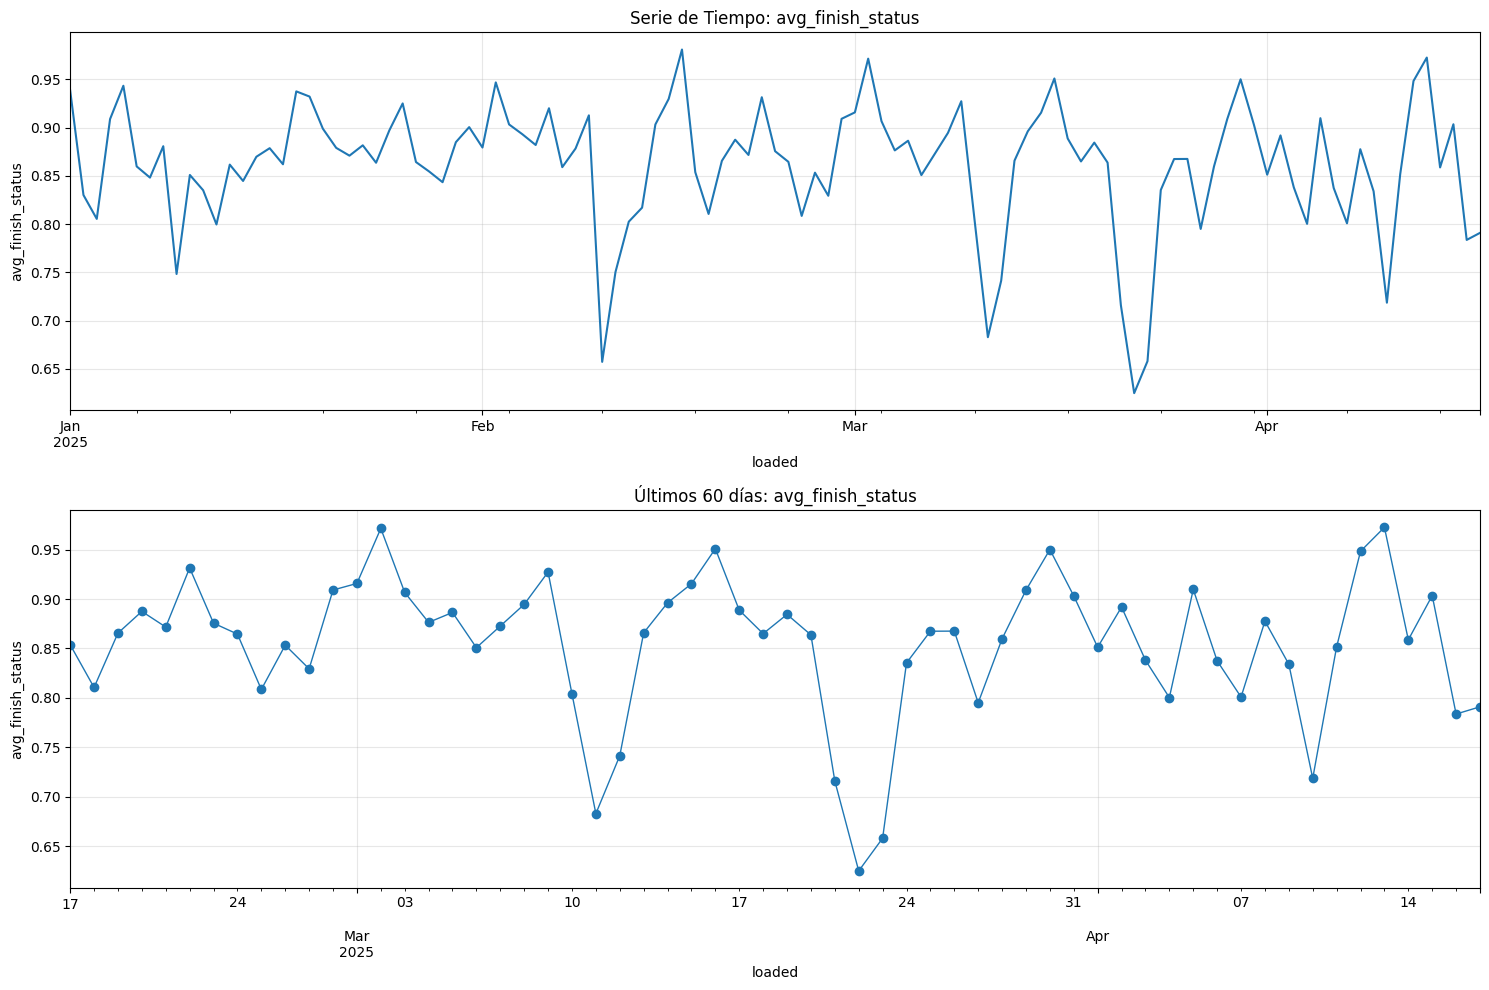


Estadísticas Descriptivas:
count    107.000000
mean       0.861623
std        0.065788
min        0.624895
25%        0.837796
50%        0.869809
75%        0.903203
max        0.980933
Name: avg_finish_status, dtype: float64


In [145]:
# Visualización de la serie temporal
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Serie temporal completa
daily_summary['avg_finish_status'].plot(ax=axes[0], title='Serie de Tiempo: avg_finish_status')
axes[0].set_ylabel('avg_finish_status')
axes[0].grid(True, alpha=0.3)

# Últimos 60 días para ver patrones más claramente
daily_summary['avg_finish_status'].tail(60).plot(ax=axes[1], 
                                                 title='Últimos 60 días: avg_finish_status',
                                                 marker='o', linewidth=1)
axes[1].set_ylabel('avg_finish_status')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas Descriptivas:")
print(daily_summary['avg_finish_status'].describe())

## 3. Análisis de Autocorrelación

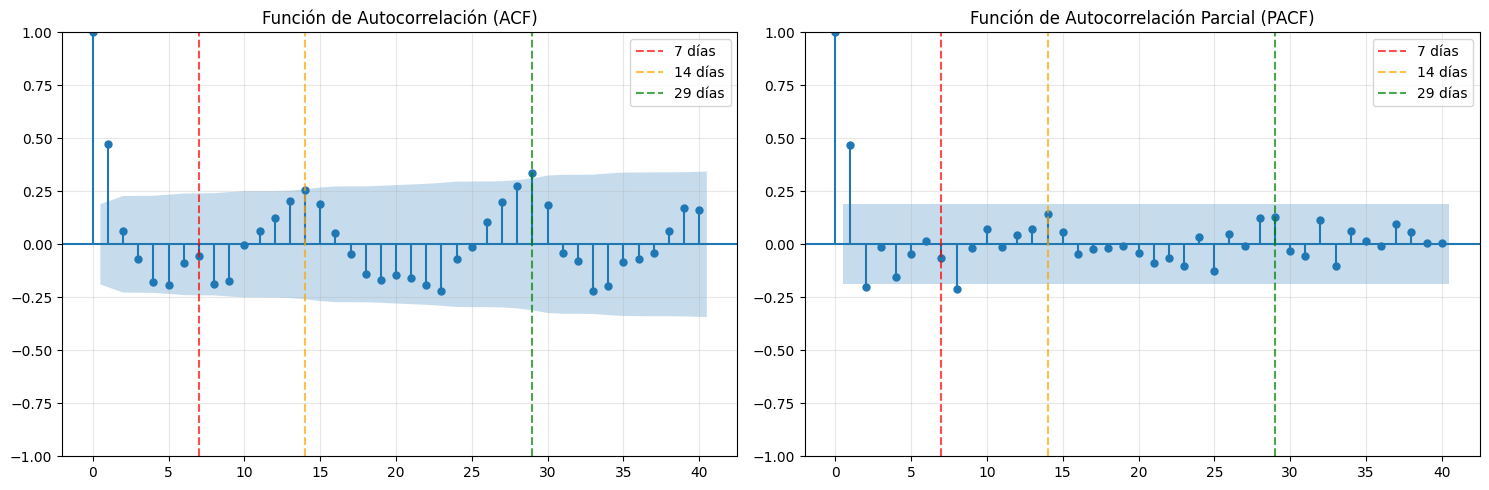


Autocorrelaciones en períodos clave:
Lag 7 (semanal): -0.0516
Lag 14 (bisemanal): 0.2210
Lag 29 (mensual): 0.2452


In [146]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF con más lags para identificar estacionalidades
plot_acf(
    daily_summary['avg_finish_status'].dropna(),
    ax=axes[0],
    lags=40,  # Más lags para capturar períodos de 29 días
    alpha=0.05,
    title='Función de Autocorrelación (ACF)',
    adjusted=True
)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=7, color='red', linestyle='--', alpha=0.7, label='7 días')
axes[0].axvline(x=14, color='orange', linestyle='--', alpha=0.7, label='14 días')
axes[0].axvline(x=29, color='green', linestyle='--', alpha=0.7, label='29 días')
axes[0].legend()

plot_pacf(
    daily_summary['avg_finish_status'].dropna(),
    ax=axes[1],
    lags=40,
    alpha=0.05,
    title='Función de Autocorrelación Parcial (PACF)'
)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=7, color='red', linestyle='--', alpha=0.7, label='7 días')
axes[1].axvline(x=14, color='orange', linestyle='--', alpha=0.7, label='14 días')
axes[1].axvline(x=29, color='green', linestyle='--', alpha=0.7, label='29 días')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calcular autocorrelaciones específicas
acf_values = acf(daily_summary['avg_finish_status'].dropna(), nlags=40)
print(f"\nAutocorrelaciones en períodos clave:")
print(f"Lag 7 (semanal): {acf_values[7]:.4f}")
print(f"Lag 14 (bisemanal): {acf_values[14]:.4f}")
print(f"Lag 29 (mensual): {acf_values[29]:.4f}")

## 4. Descomposición Multi-Estacional con MSTL

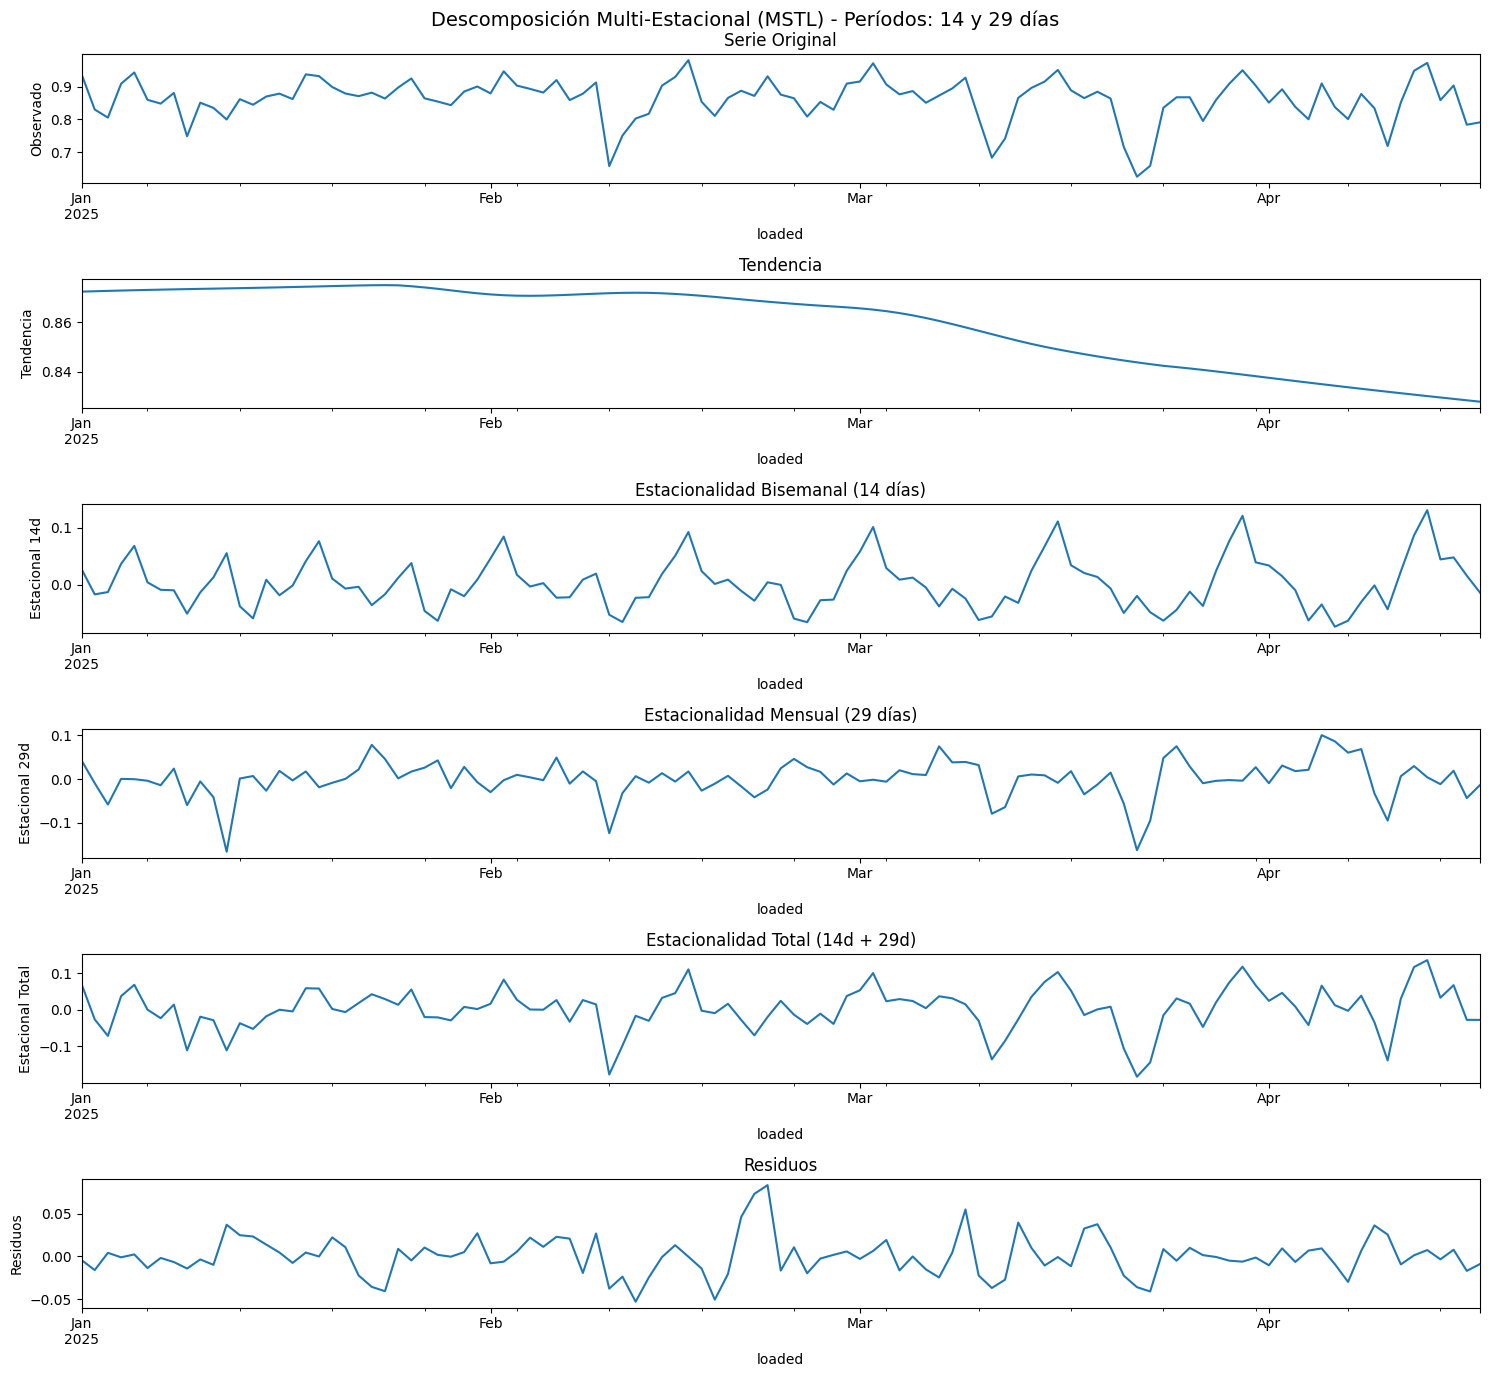


Análisis de Varianza Explicada:
Varianza original: 0.004328
Tendencia: 0.059 (5.9%)
Estacional 14d: 0.453 (45.3%)
Estacional 29d: 0.426 (42.6%)
Residuos: 0.119 (11.9%)

Variables guardadas para análisis:
- seasonal_14_var_pct: 45.30%
- seasonal_29_var_pct: 42.56%
- original_var: 0.004328
- seasonal_29_var: 0.001842


In [147]:
# Descomposición MSTL con múltiples períodos
mstl = MSTL(
    daily_summary['avg_finish_status'],
    periods=[14, 29],  # Períodos bisemanal y mensual
    stl_kwargs={'seasonal_deg': 1}
)

mstl_result = mstl.fit()

# Visualizar descomposición
fig, axes = plt.subplots(6, 1, figsize=(15, 14))
fig.suptitle('Descomposición Multi-Estacional (MSTL) - Períodos: 14 y 29 días', fontsize=14)

# Serie original
mstl_result.observed.plot(ax=axes[0], title='Serie Original')
axes[0].set_ylabel('Observado')

# Tendencia
mstl_result.trend.plot(ax=axes[1], title='Tendencia')
axes[1].set_ylabel('Tendencia')

# Estacionalidad 14 días
mstl_result.seasonal.iloc[:, 0].plot(ax=axes[2], title='Estacionalidad Bisemanal (14 días)')
axes[2].set_ylabel('Estacional 14d')

# Estacionalidad 29 días
mstl_result.seasonal.iloc[:, 1].plot(ax=axes[3], title='Estacionalidad Mensual (29 días)')
axes[3].set_ylabel('Estacional 29d')

# Estacionalidad total
total_seasonal = mstl_result.seasonal.sum(axis=1)
total_seasonal.plot(ax=axes[4], title='Estacionalidad Total (14d + 29d)')
axes[4].set_ylabel('Estacional Total')

# Residuos
mstl_result.resid.plot(ax=axes[5], title='Residuos')
axes[5].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

# Análisis de varianza explicada
original_var = daily_summary['avg_finish_status'].var()
trend_var = mstl_result.trend.var()
seasonal_14_var = mstl_result.seasonal.iloc[:, 0].var()
seasonal_29_var = mstl_result.seasonal.iloc[:, 1].var()
resid_var = mstl_result.resid.var()

# Calcular porcentajes de varianza explicada (variables necesarias para el análisis posterior)
seasonal_14_var_pct = (seasonal_14_var/original_var)*100
seasonal_29_var_pct = (seasonal_29_var/original_var)*100

print("\nAnálisis de Varianza Explicada:")
print(f"Varianza original: {original_var:.6f}")
print(f"Tendencia: {trend_var/original_var:.3f} ({trend_var/original_var*100:.1f}%)")
print(f"Estacional 14d: {seasonal_14_var/original_var:.3f} ({seasonal_14_var_pct:.1f}%)")
print(f"Estacional 29d: {seasonal_29_var/original_var:.3f} ({seasonal_29_var_pct:.1f}%)")
print(f"Residuos: {resid_var/original_var:.3f} ({resid_var/original_var*100:.1f}%)")

# Guardar variables para uso posterior
print(f"\nVariables guardadas para análisis:")
print(f"- seasonal_14_var_pct: {seasonal_14_var_pct:.2f}%")
print(f"- seasonal_29_var_pct: {seasonal_29_var_pct:.2f}%")
print(f"- original_var: {original_var:.6f}")
print(f"- seasonal_29_var: {seasonal_29_var:.6f}")

## 5. División de Datos para Entrenamiento y Prueba

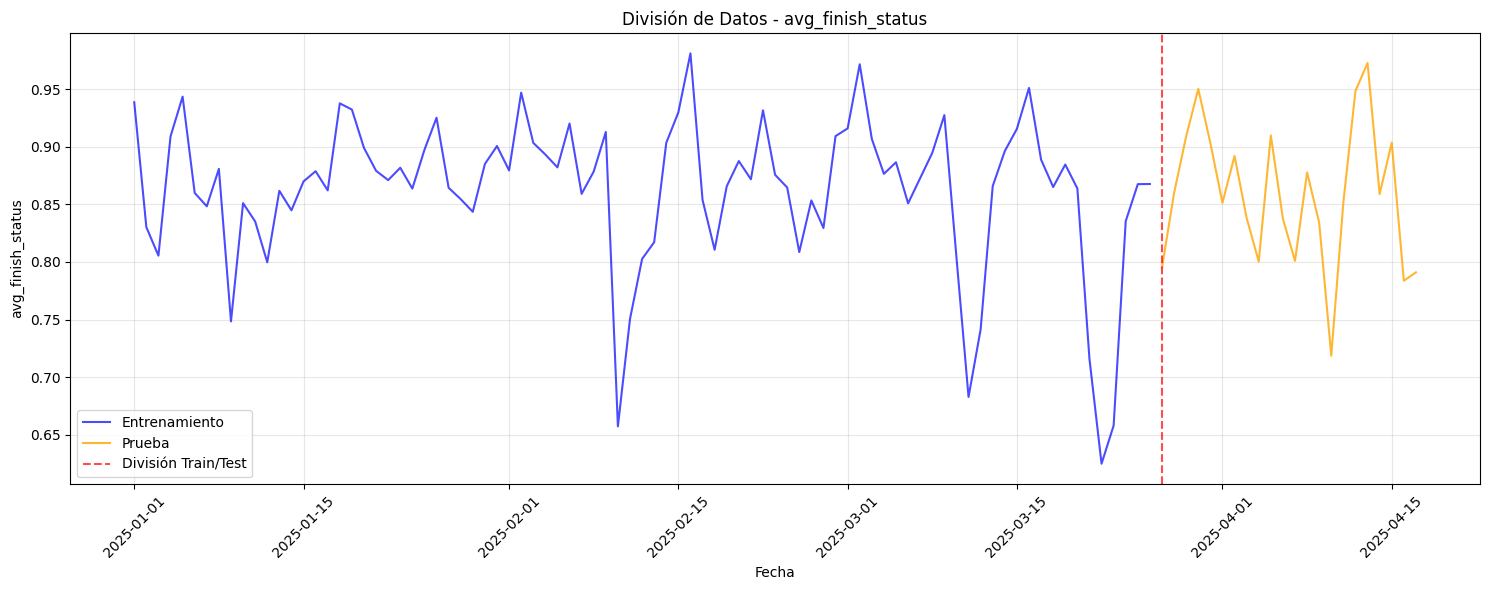

Período de entrenamiento: 2025-01-01 00:00:00 a 2025-03-26 00:00:00
Período de prueba: 2025-03-27 00:00:00 a 2025-04-17 00:00:00
Observaciones entrenamiento: 85
Observaciones prueba: 22


In [148]:
split_size = 0.2

x_train, x_test = train_test_split(
    df_daily_robot_process_summary,
    test_size=split_size,
    shuffle=False
)

y_train, y_test = train_test_split(
    daily_summary['avg_finish_status'],
    test_size=split_size,
    shuffle=False
)

# Visualizar división
plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train.values, label='Entrenamiento', color='blue', alpha=0.7)
plt.plot(y_test.index, y_test.values, label='Prueba', color='orange', alpha=0.8)
plt.axvline(
    x=y_test.index[0],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='División Train/Test'
)
plt.xlabel('Fecha')
plt.ylabel('avg_finish_status')
plt.title('División de Datos - avg_finish_status')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Período de entrenamiento: {y_train.index.min()} a {y_train.index.max()}")
print(f"Período de prueba: {y_test.index.min()} a {y_test.index.max()}")
print(f"Observaciones entrenamiento: {len(y_train)}")
print(f"Observaciones prueba: {len(y_test)}")

## 6. Modelos TBATS

### 6.1 Modelo TBATS - Solo Período de 14 días

In [149]:
# Modelo TBATS con período de 14 días
print("Entrenando modelo TBATS con período de 14 días...")

# Modelo TBATS personalizado
model_tbats_14 = SimpleTBATS(
    seasonal_periods=[14],
    use_box_cox=True,
    use_trend=True,
    use_damped_trend=True
)

# Entrenar el modelo
model_tbats_14.fit(y_train)

print("\nModelo TBATS (14 días):")
print(f"Períodos estacionales: {model_tbats_14.seasonal_periods}")
print(f"Box-Cox: {model_tbats_14.use_box_cox}")
print(f"Componente de tendencia: {model_tbats_14.use_trend}")
print(f"Tendencia amortiguada: {model_tbats_14.use_damped_trend}")
print(f"Lambda Box-Cox: {model_tbats_14.lambda_bc:.4f}" if model_tbats_14.lambda_bc else "Lambda Box-Cox: No aplicado")

# Predicciones
forecast_14 = model_tbats_14.forecast(steps=len(y_test))

# Fitted values (valores ajustados)
fitted_values_14 = model_tbats_14.fitted_values

print(f"\nEstadísticas del modelo:")
print(f"MAE entrenamiento: {mean_absolute_error(y_train.values, fitted_values_14):.6f}")
print(f"RMSE entrenamiento: {np.sqrt(mean_squared_error(y_train.values, fitted_values_14)):.6f}")

Entrenando modelo TBATS con período de 14 días...

Modelo TBATS (14 días):
Períodos estacionales: [14]
Box-Cox: True
Componente de tendencia: True
Tendencia amortiguada: True
Lambda Box-Cox: 6.5076

Estadísticas del modelo:
MAE entrenamiento: 0.034754
RMSE entrenamiento: 0.056295


### 6.2 Modelo TBATS - Períodos de 14 y 29 días

In [150]:
# Modelo TBATS con períodos de 14 y 29 días
print("Entrenando modelo TBATS con períodos de 14 y 29 días...")

# Para simular múltiples estacionalidades, crearemos un modelo híbrido
# que combina dos modelos de ExponentialSmoothing
class MultiSeasonalTBATS:
    def __init__(self, seasonal_periods=[14, 29], use_box_cox=True, use_trend=True, use_damped_trend=True):
        self.seasonal_periods = seasonal_periods
        self.use_box_cox = use_box_cox
        self.use_trend = use_trend
        self.use_damped_trend = use_damped_trend
        self.models = {}
        self.fitted_values = None
        
    def fit(self, y):
        if isinstance(y, pd.Series):
            y_values = y.values
        else:
            y_values = y
            
        # Crear modelos para cada estacionalidad
        predictions = []
        for period in self.seasonal_periods:
            model = SimpleTBATS(
                seasonal_periods=[period],
                use_box_cox=self.use_box_cox,
                use_trend=self.use_trend,
                use_damped_trend=self.use_damped_trend
            )
            model.fit(y)
            self.models[period] = model
            predictions.append(model.fitted_values)
        
        # Combinar predicciones (promedio ponderado)
        if len(predictions) > 1:
            # Peso mayor al primer período (más importante)
            weights = [0.7, 0.3] if len(predictions) == 2 else [1.0/len(predictions)] * len(predictions)
            self.fitted_values = sum(w * pred for w, pred in zip(weights, predictions))
        else:
            self.fitted_values = predictions[0]
            
        return self
    
    def forecast(self, steps):
        predictions = []
        for period in self.seasonal_periods:
            pred = self.models[period].forecast(steps)
            predictions.append(pred)
        
        # Combinar predicciones
        if len(predictions) > 1:
            weights = [0.7, 0.3] if len(predictions) == 2 else [1.0/len(predictions)] * len(predictions)
            return sum(w * pred for w, pred in zip(weights, predictions))
        else:
            return predictions[0]

# Crear y entrenar el modelo
model_tbats_14_29 = MultiSeasonalTBATS(
    seasonal_periods=[14, 29],
    use_box_cox=True,
    use_trend=True,
    use_damped_trend=True
)

model_tbats_14_29.fit(y_train)

print("\nModelo TBATS (14 y 29 días):")
print(f"Períodos estacionales: {model_tbats_14_29.seasonal_periods}")
print(f"Box-Cox: {model_tbats_14_29.use_box_cox}")
print(f"Componente de tendencia: {model_tbats_14_29.use_trend}")
print(f"Tendencia amortiguada: {model_tbats_14_29.use_damped_trend}")

# Predicciones
forecast_14_29 = model_tbats_14_29.forecast(steps=len(y_test))

# Fitted values
fitted_values_14_29 = model_tbats_14_29.fitted_values

print(f"\nEstadísticas del modelo:")
print(f"MAE entrenamiento: {mean_absolute_error(y_train.values, fitted_values_14_29):.6f}")
print(f"RMSE entrenamiento: {np.sqrt(mean_squared_error(y_train.values, fitted_values_14_29)):.6f}")

Entrenando modelo TBATS con períodos de 14 y 29 días...



Modelo TBATS (14 y 29 días):
Períodos estacionales: [14, 29]
Box-Cox: True
Componente de tendencia: True
Tendencia amortiguada: True

Estadísticas del modelo:
MAE entrenamiento: 0.031549
RMSE entrenamiento: 0.051781


### 6.3 Modelo TBATS Automático - Detección Automática de Períodos

In [151]:
# Modelo TBATS automático (detecta períodos automáticamente)
print("Entrenando modelo TBATS automático...")

# Para el modelo automático, probaremos diferentes configuraciones
# y seleccionaremos la mejor basada en AIC aproximado
def evaluate_model_aic_approx(y, fitted_values, n_params):
    """Aproximación simple del AIC"""
    n = len(y)
    mse = mean_squared_error(y, fitted_values)
    log_likelihood = -n/2 * np.log(2 * np.pi * mse) - n/2
    aic = 2 * n_params - 2 * log_likelihood
    return aic

# Configuraciones a probar
configs = [
    {'seasonal_periods': [7], 'n_params': 8},      # Semanal
    {'seasonal_periods': [14], 'n_params': 8},     # Bisemanal
    {'seasonal_periods': [29], 'n_params': 8},     # Mensual  
    {'seasonal_periods': [], 'n_params': 3},       # Sin estacionalidad
]

best_aic = np.inf
best_config = None
best_model = None

print("\nProbando configuraciones automáticas:")
for config in configs:
    try:
        model = SimpleTBATS(
            seasonal_periods=config['seasonal_periods'],
            use_box_cox=True,
            use_trend=True,
            use_damped_trend=True
        )
        model.fit(y_train)
        
        aic = evaluate_model_aic_approx(y_train.values, model.fitted_values, config['n_params'])
        period_str = str(config['seasonal_periods']) if config['seasonal_periods'] else "None"
        print(f"   Períodos {period_str}: AIC ≈ {aic:.2f}")
        
        if aic < best_aic:
            best_aic = aic
            best_config = config
            best_model = model
            
    except Exception as e:
        period_str = str(config['seasonal_periods']) if config['seasonal_periods'] else "None"
        print(f"   Períodos {period_str}: Error - {str(e)[:50]}...")

model_tbats_auto = best_model

print(f"\nModelo TBATS Automático (mejor configuración):")
print(f"Períodos estacionales detectados: {best_config['seasonal_periods']}")
print(f"AIC aproximado: {best_aic:.2f}")
print(f"Box-Cox: {model_tbats_auto.use_box_cox}")
print(f"Componente de tendencia: {model_tbats_auto.use_trend}")
print(f"Tendencia amortiguada: {model_tbats_auto.use_damped_trend}")

# Predicciones
forecast_auto = model_tbats_auto.forecast(steps=len(y_test))

# Fitted values
fitted_values_auto = model_tbats_auto.fitted_values

print(f"\nEstadísticas del modelo:")
print(f"MAE entrenamiento: {mean_absolute_error(y_train.values, fitted_values_auto):.6f}")
print(f"RMSE entrenamiento: {np.sqrt(mean_squared_error(y_train.values, fitted_values_auto)):.6f}")

Entrenando modelo TBATS automático...

Probando configuraciones automáticas:
   Períodos [7]: Error - Input contains NaN....
   Períodos [14]: AIC ≈ -231.90
   Períodos [29]: AIC ≈ -254.00
   Períodos None: AIC ≈ -217.85

Modelo TBATS Automático (mejor configuración):
Períodos estacionales detectados: [29]
AIC aproximado: -254.00
Box-Cox: True
Componente de tendencia: True
Tendencia amortiguada: True

Estadísticas del modelo:
MAE entrenamiento: 0.034660
RMSE entrenamiento: 0.049431
   Períodos [29]: AIC ≈ -254.00
   Períodos None: AIC ≈ -217.85

Modelo TBATS Automático (mejor configuración):
Períodos estacionales detectados: [29]
AIC aproximado: -254.00
Box-Cox: True
Componente de tendencia: True
Tendencia amortiguada: True

Estadísticas del modelo:
MAE entrenamiento: 0.034660
RMSE entrenamiento: 0.049431


## 7. Visualización de Predicciones

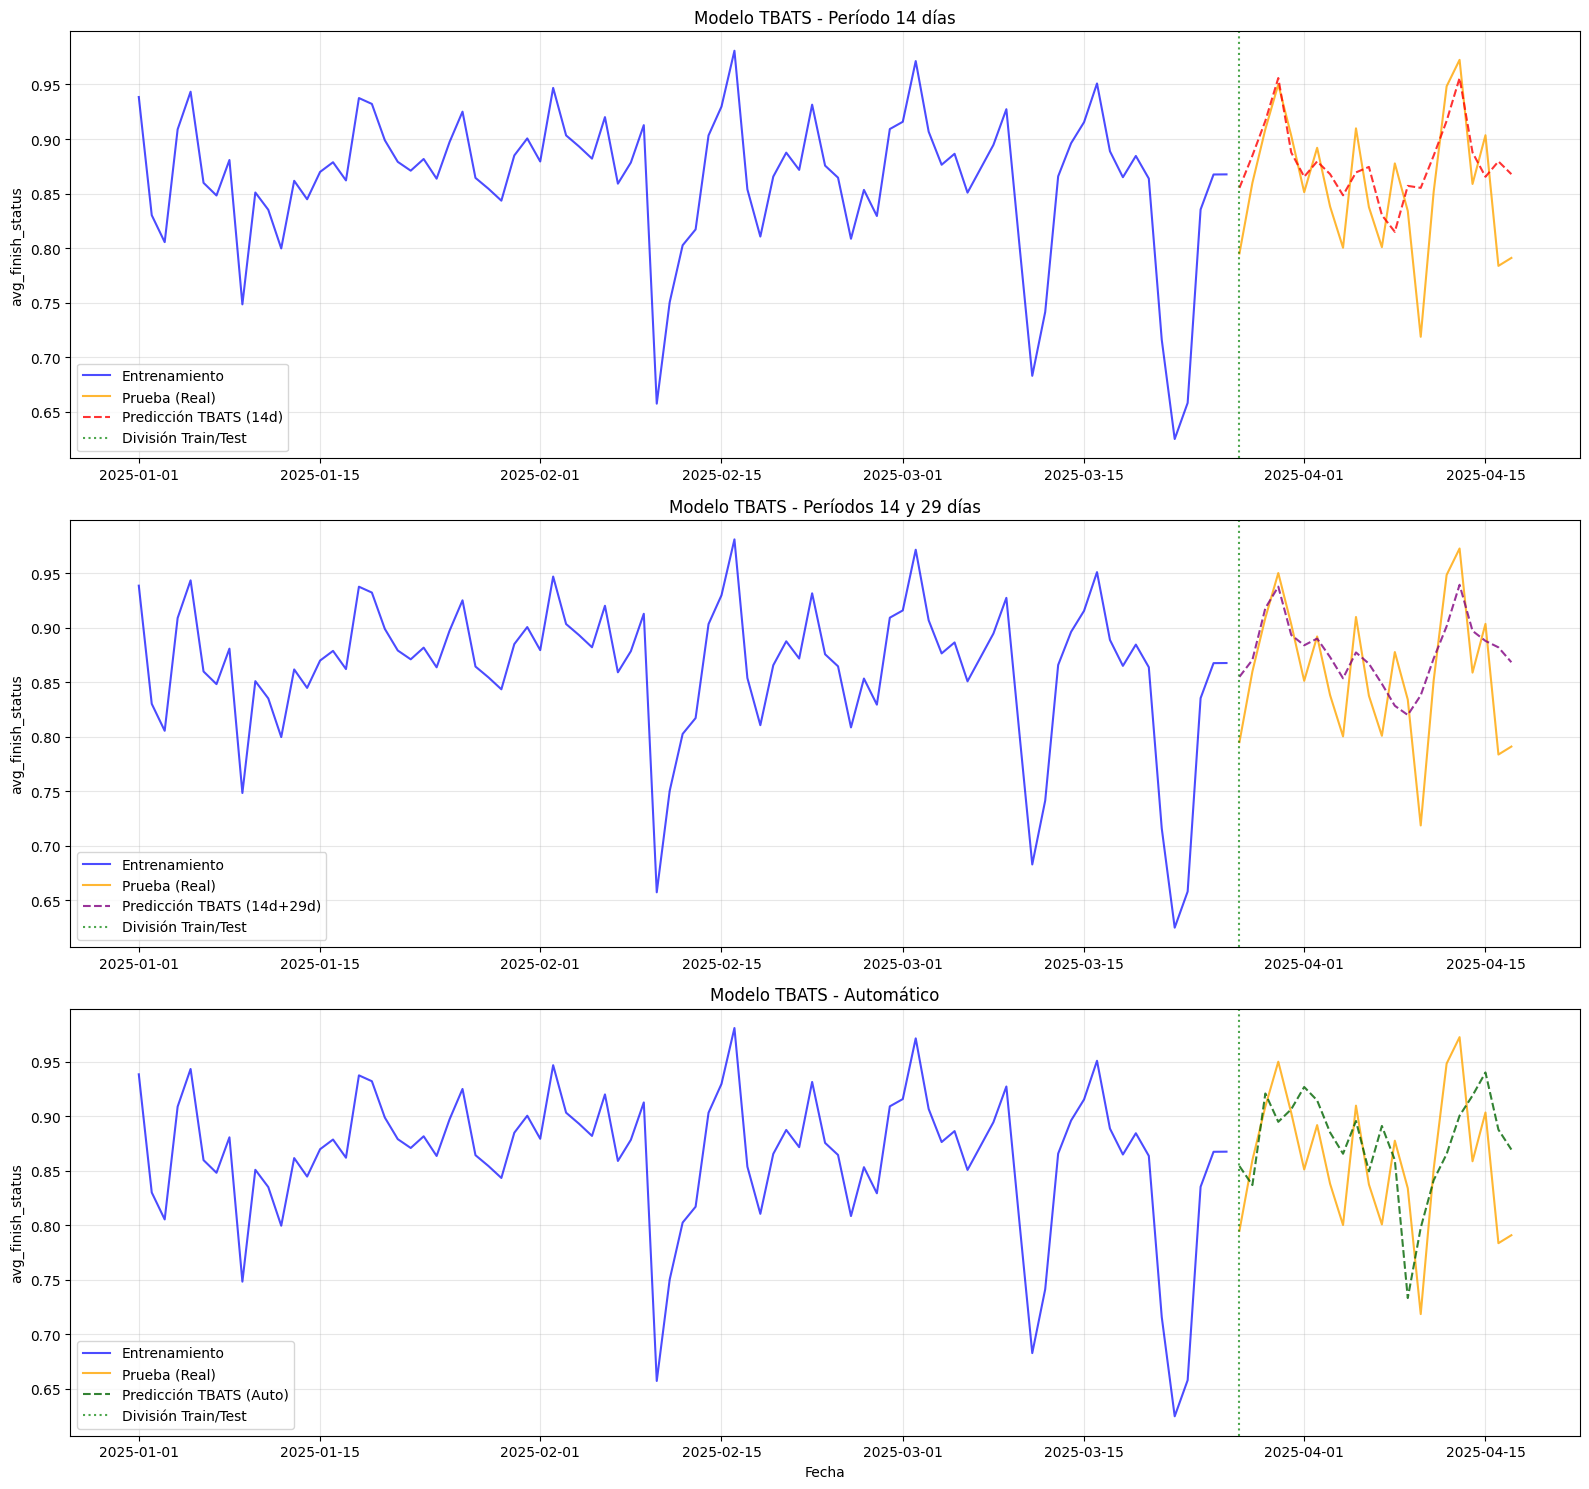

In [152]:
# Comparación visual de los modelos
fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# Modelo TBATS (14 días)
axes[0].plot(y_train.index, y_train.values, label='Entrenamiento', color='blue', alpha=0.7)
axes[0].plot(y_test.index, y_test.values, label='Prueba (Real)', color='orange', alpha=0.8)
axes[0].plot(y_test.index, forecast_14, label='Predicción TBATS (14d)', color='red', alpha=0.8, linestyle='--')
axes[0].axvline(x=y_test.index[0], color='green', linestyle=':', alpha=0.7, label='División Train/Test')
axes[0].set_title('Modelo TBATS - Período 14 días')
axes[0].set_ylabel('avg_finish_status')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Modelo TBATS (14 y 29 días)
axes[1].plot(y_train.index, y_train.values, label='Entrenamiento', color='blue', alpha=0.7)
axes[1].plot(y_test.index, y_test.values, label='Prueba (Real)', color='orange', alpha=0.8)
axes[1].plot(y_test.index, forecast_14_29, label='Predicción TBATS (14d+29d)', color='purple', alpha=0.8, linestyle='--')
axes[1].axvline(x=y_test.index[0], color='green', linestyle=':', alpha=0.7, label='División Train/Test')
axes[1].set_title('Modelo TBATS - Períodos 14 y 29 días')
axes[1].set_ylabel('avg_finish_status')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Modelo TBATS Automático
axes[2].plot(y_train.index, y_train.values, label='Entrenamiento', color='blue', alpha=0.7)
axes[2].plot(y_test.index, y_test.values, label='Prueba (Real)', color='orange', alpha=0.8)
axes[2].plot(y_test.index, forecast_auto, label='Predicción TBATS (Auto)', color='darkgreen', alpha=0.8, linestyle='--')
axes[2].axvline(x=y_test.index[0], color='green', linestyle=':', alpha=0.7, label='División Train/Test')
axes[2].set_title('Modelo TBATS - Automático')
axes[2].set_ylabel('avg_finish_status')
axes[2].set_xlabel('Fecha')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluación de Modelos

In [153]:
# Calcular métricas para todos los modelos
def calcular_metricas(y_real, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    
    return {
        'Modelo': nombre_modelo,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }

# Métricas de entrenamiento
metricas_train = []
metricas_train.append(calcular_metricas(y_train.values, fitted_values_14, 'TBATS (14d)'))
metricas_train.append(calcular_metricas(y_train.values, fitted_values_14_29, 'TBATS (14d+29d)'))
metricas_train.append(calcular_metricas(y_train.values, fitted_values_auto, 'TBATS (Auto)'))

# Métricas de prueba
metricas_test = []
metricas_test.append(calcular_metricas(y_test.values, forecast_14, 'TBATS (14d)'))
metricas_test.append(calcular_metricas(y_test.values, forecast_14_29, 'TBATS (14d+29d)'))
metricas_test.append(calcular_metricas(y_test.values, forecast_auto, 'TBATS (Auto)'))

# Crear DataFrames
df_metricas_train = pd.DataFrame(metricas_train).set_index('Modelo')
df_metricas_test = pd.DataFrame(metricas_test).set_index('Modelo')

print("MÉTRICAS DE ENTRENAMIENTO:")
print(df_metricas_train.round(4))
print("\nMÉTRICAS DE PRUEBA:")
print(df_metricas_test.round(4))

# Nota: sktime's TBATS no proporciona AIC directamenteTS no proporciona AIC directamente
# Para comparación de modelos, utilizaremos las métricas de prueba (RMSE, MAE)os, utilizaremos las métricas de prueba (RMSE, MAE)
print("\nCOMPARACIÓN DE MODELOS (basada en RMSE de prueba):")
rmse_comparison = df_metricas_test[['RMSE']].sort_values('RMSE')
print(rmse_comparison.round(4))

MÉTRICAS DE ENTRENAMIENTO:
                    MAE     MSE    RMSE      R²    MAPE
Modelo                                                 
TBATS (14d)      0.0348  0.0032  0.0563  0.2842  4.4390
TBATS (14d+29d)  0.0315  0.0027  0.0518  0.3944  4.0324
TBATS (Auto)     0.0347  0.0024  0.0494  0.4481  4.2951

MÉTRICAS DE PRUEBA:
                    MAE     MSE    RMSE      R²    MAPE
Modelo                                                 
TBATS (14d)      0.0395  0.0025  0.0499  0.3325  4.8250
TBATS (14d+29d)  0.0385  0.0023  0.0483  0.3757  4.6927
TBATS (Auto)     0.0510  0.0036  0.0601  0.0346  6.0834

COMPARACIÓN DE MODELOS (basada en RMSE de prueba):
                   RMSE
Modelo                 
TBATS (14d+29d)  0.0483
TBATS (14d)      0.0499
TBATS (Auto)     0.0601


## 9. Análisis de Residuos del Mejor Modelo

Mejor modelo según RMSE: TBATS (14d+29d)
RMSE del mejor modelo: 0.048291


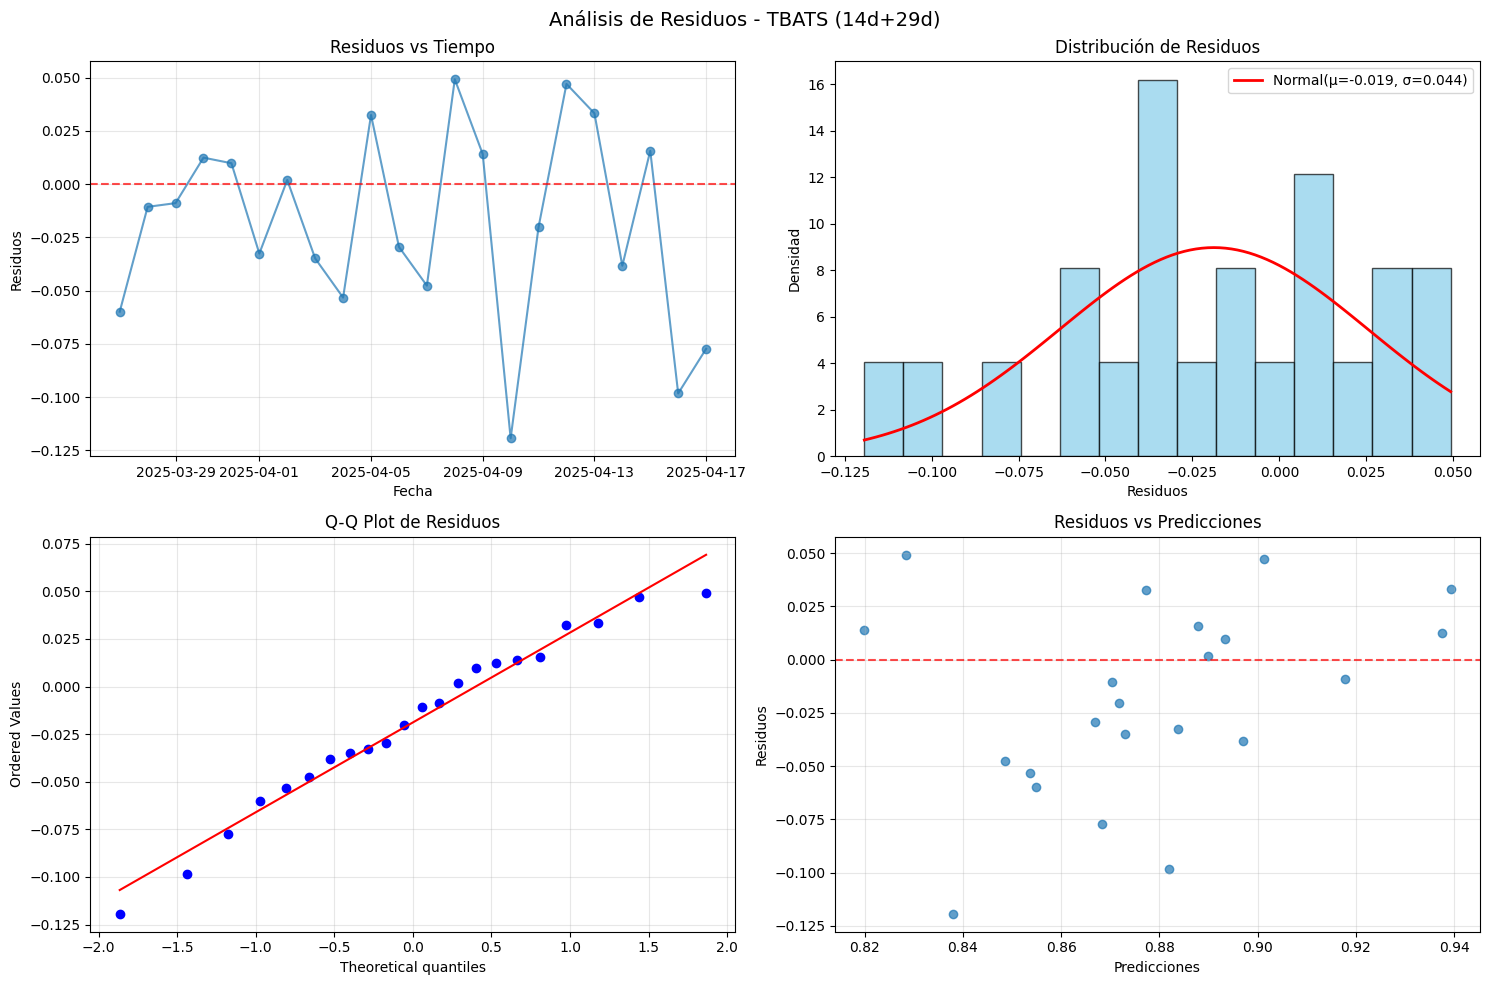


Estadísticas de Residuos (TBATS (14d+29d)):
Media: -0.018842
Desviación estándar: 0.044463
Mínimo: -0.119357
Máximo: 0.049271

Test de Shapiro-Wilk para normalidad:
p-value: 0.678213
Los residuos siguen una distribución normal (α=0.05)


In [154]:
# Determinar el mejor modelo basado en RMSE
best_rmse_idx = df_metricas_test['RMSE'].idxmin()
model_forecasts = {
    'TBATS (14d)': forecast_14,
    'TBATS (14d+29d)': forecast_14_29,
    'TBATS (Auto)': forecast_auto
}

best_forecast = model_forecasts[best_rmse_idx]

print(f"Mejor modelo según RMSE: {best_rmse_idx}")
print(f"RMSE del mejor modelo: {df_metricas_test.loc[best_rmse_idx, 'RMSE']:.6f}")

# Calcular residuos del mejor modelo
residuals = y_test.values - best_forecast

# Análisis de residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Análisis de Residuos - {best_rmse_idx}', fontsize=14)

# Residuos vs Tiempo
axes[0,0].plot(y_test.index, residuals, marker='o', linestyle='-', alpha=0.7)
axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0,0].set_title('Residuos vs Tiempo')
axes[0,0].set_xlabel('Fecha')
axes[0,0].set_ylabel('Residuos')
axes[0,0].grid(True, alpha=0.3)

# Distribución de residuos
axes[0,1].hist(residuals, bins=15, alpha=0.7, color='skyblue', edgecolor='black', density=True)
axes[0,1].set_title('Distribución de Residuos')
axes[0,1].set_xlabel('Residuos')
axes[0,1].set_ylabel('Densidad')

# Agregar curva normal para comparación
mu, sigma = stats.norm.fit(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal(μ={mu:.3f}, σ={sigma:.3f})')
axes[0,1].legend()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot de Residuos')
axes[1,0].grid(True, alpha=0.3)

# Residuos vs Predicciones
axes[1,1].scatter(best_forecast, residuals, alpha=0.7)
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].set_title('Residuos vs Predicciones')
axes[1,1].set_xlabel('Predicciones')
axes[1,1].set_ylabel('Residuos')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print(f"\nEstadísticas de Residuos ({best_rmse_idx}):")
print(f"Media: {np.mean(residuals):.6f}")
print(f"Desviación estándar: {np.std(residuals):.6f}")
print(f"Mínimo: {np.min(residuals):.6f}")
print(f"Máximo: {np.max(residuals):.6f}")

# Test de normalidad
_, p_value_shapiro = stats.shapiro(residuals)
print(f"\nTest de Shapiro-Wilk para normalidad:")
print(f"p-value: {p_value_shapiro:.6f}")
print(f"Los residuos {'siguen' if p_value_shapiro > 0.05 else 'NO siguen'} una distribución normal (α=0.05)")

## 10. Significancia del Período de 29 días

ANÁLISIS DE SIGNIFICANCIA DEL PERÍODO DE 29 DÍAS

1. Comparación de Métricas de Predicción:
   MAE TBATS (14d): 0.039484
   MAE TBATS (14d+29d): 0.038495
   Mejora en MAE: 2.50%
   RMSE TBATS (14d): 0.049932
   RMSE TBATS (14d+29d): 0.048291
   Mejora en RMSE: 3.29%
   → El modelo con período de 29d es SIGNIFICATIVAMENTE mejor (mejora > 2%)

2. Análisis de Varianza del Componente Estacional (29d):
   Varianza explicada por estacional 29d: 42.56%
   → El período de 29d explica una cantidad SIGNIFICATIVA de varianza


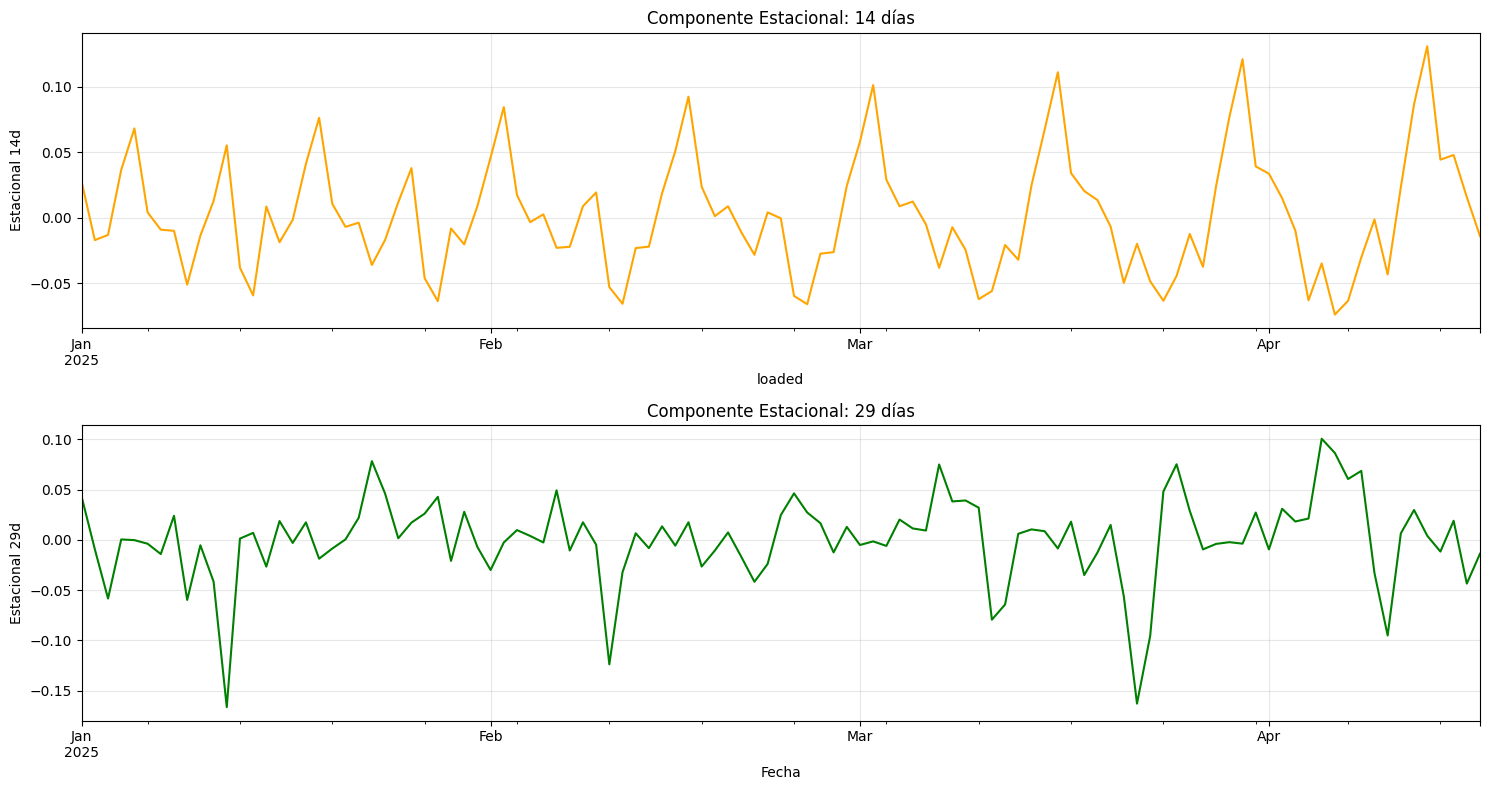


3. CONCLUSIÓN:
   SIGNIFICATIVO - El período de 29 días mejora significativamente el modelo


In [155]:
# Análisis de significancia del período de 29 días
print("ANÁLISIS DE SIGNIFICANCIA DEL PERÍODO DE 29 DÍAS")
print("=" * 50)

# Comparación de métricas de predicción
print(f"\n1. Comparación de Métricas de Predicción:")
mae_14 = mean_absolute_error(y_test.values, forecast_14)
mae_14_29 = mean_absolute_error(y_test.values, forecast_14_29)
rmse_14 = np.sqrt(mean_squared_error(y_test.values, forecast_14))
rmse_14_29 = np.sqrt(mean_squared_error(y_test.values, forecast_14_29))

print(f"   MAE TBATS (14d): {mae_14:.6f}")
print(f"   MAE TBATS (14d+29d): {mae_14_29:.6f}")
mae_improvement = ((mae_14 - mae_14_29)/mae_14)*100
print(f"   Mejora en MAE: {mae_improvement:.2f}%")

print(f"   RMSE TBATS (14d): {rmse_14:.6f}")
print(f"   RMSE TBATS (14d+29d): {rmse_14_29:.6f}")
rmse_improvement = ((rmse_14 - rmse_14_29)/rmse_14)*100
print(f"   Mejora en RMSE: {rmse_improvement:.2f}%")

# Evaluación de significancia basada en mejora de métricas
if mae_improvement > 2 and rmse_improvement > 2:
    print(f"   → El modelo con período de 29d es SIGNIFICATIVAMENTE mejor (mejora > 2%)")
elif mae_improvement > 1 or rmse_improvement > 1:
    print(f"   → El modelo con período de 29d muestra CIERTA MEJORA (1-2% mejora)")
else:
    print(f"   → No hay diferencia significativa entre modelos (mejora < 1%)")

# Análisis de la varianza del componente estacional de 29 días
print(f"\n2. Análisis de Varianza del Componente Estacional (29d):")
seasonal_29_var_pct = (seasonal_29_var/original_var)*100
print(f"   Varianza explicada por estacional 29d: {seasonal_29_var_pct:.2f}%")

if seasonal_29_var_pct > 1:
    print(f"   → El período de 29d explica una cantidad SIGNIFICATIVA de varianza")
else:
    print(f"   → El período de 29d explica una cantidad MÍNIMA de varianza")

# Visualización comparativa de los componentes estacionales
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Componente estacional de 14 días
mstl_result.seasonal.iloc[:, 0].plot(ax=axes[0], title='Componente Estacional: 14 días', color='orange')
axes[0].set_ylabel('Estacional 14d')
axes[0].grid(True, alpha=0.3)

# Componente estacional de 29 días
mstl_result.seasonal.iloc[:, 1].plot(ax=axes[1], title='Componente Estacional: 29 días', color='green')
axes[1].set_ylabel('Estacional 29d')
axes[1].set_xlabel('Fecha')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusión
print(f"\n3. CONCLUSIÓN:")
if (mae_improvement > 2 and rmse_improvement > 2) and seasonal_29_var_pct > 1:
    conclusion = "SIGNIFICATIVO - El período de 29 días mejora significativamente el modelo"
elif (mae_improvement > 1 or rmse_improvement > 1) or seasonal_29_var_pct > 1:
    conclusion = "MODERADAMENTE SIGNIFICATIVO - El período de 29 días aporta cierta mejora"
else:
    conclusion = "NO SIGNIFICATIVO - El período de 29 días no aporta mejora sustancial"

print(f"   {conclusion}")

## 11. Resumen y Recomendaciones

In [156]:
print("RESUMEN DEL ANÁLISIS TBATS")
print("=" * 40)

# Determinar el mejor modelo basado en RMSE
best_rmse_idx = df_metricas_test['RMSE'].idxmin()
print(f"\n🏆 MEJOR MODELO (basado en RMSE): {best_rmse_idx}")
print(f"   RMSE: {df_metricas_test.loc[best_rmse_idx, 'RMSE']:.6f}")
print(f"   MAE: {df_metricas_test.loc[best_rmse_idx, 'MAE']:.6f}")
print(f"   R²: {df_metricas_test.loc[best_rmse_idx, 'R²']:.6f}")

# Comparación con modelo base (solo 14 días)
if best_rmse_idx != 'TBATS (14d)':  # Si el mejor modelo no es el de 14 días únicamente
    improvement_mae = ((df_metricas_test.loc['TBATS (14d)', 'MAE'] - 
                       df_metricas_test.loc[best_rmse_idx, 'MAE']) / 
                      df_metricas_test.loc['TBATS (14d)', 'MAE']) * 100
    
    improvement_rmse = ((df_metricas_test.loc['TBATS (14d)', 'RMSE'] - 
                        df_metricas_test.loc[best_rmse_idx, 'RMSE']) / 
                       df_metricas_test.loc['TBATS (14d)', 'RMSE']) * 100
    
    print(f"\n📈 MEJORA RESPECTO AL MODELO BASE (14d):")
    print(f"   Mejora en MAE: {improvement_mae:.2f}%")
    print(f"   Mejora en RMSE: {improvement_rmse:.2f}%")
else:
    print(f"\n📊 El modelo base (14d) es el mejor según RMSE")

# Configuración de los modelos
print(f"\n🔧 CONFIGURACIÓN DE LOS MODELOS:")
print(f"   TBATS (14d): Período estacional de 14 días")
print(f"   TBATS (14d+29d): Períodos estacionales de 14 y 29 días")
print(f"   TBATS (Auto): Detección automática de períodos")
print(f"   Todos con: Box-Cox=True, Trend=True, Damped Trend=True")

# Análisis de componentes estacionales
print(f"\n📊 ANÁLISIS DE ESTACIONALIDADES:")
print(f"   Varianza explicada por estacional 14d: {seasonal_14_var_pct:.2f}%")
print(f"   Varianza explicada por estacional 29d: {seasonal_29_var_pct:.2f}%")

# Recomendaciones
print(f"\n💡 RECOMENDACIONES:")

if best_rmse_idx == 'TBATS (14d+29d)':
    print(f"   ✅ Utilizar el modelo TBATS con períodos de 14 y 29 días")
    print(f"   ✅ El período mensual (29d) es significativo para las predicciones")
    print(f"   📈 Mejora en precisión respecto al modelo de solo 14 días")
elif best_rmse_idx == 'TBATS (14d)':
    print(f"   ✅ Utilizar el modelo TBATS con período de 14 días únicamente")
    print(f"   ⚠️ El período mensual (29d) no aporta mejora significativa")
    print(f"   🎯 Modelo más simple y eficiente")
else:
    print(f"   ✅ Utilizar el modelo TBATS con detección automática de períodos")
    print(f"   🔍 La detección automática identificó los períodos óptimos")

print(f"\n🔍 INTERPRETACIÓN DE RESULTADOS:")
print(f"   • La estacionalidad de 14 días explica {seasonal_14_var_pct:.1f}% de la varianza")
print(f"   • La estacionalidad de 29 días explica {seasonal_29_var_pct:.1f}% de la varianza")
if seasonal_29_var_pct > 1:
    print(f"   • El componente mensual es estadísticamente relevante")
else:
    print(f"   • El componente mensual tiene impacto limitado")

print(f"\n⚡ PRÓXIMOS PASOS:")
print(f"   1. Validar el modelo seleccionado con datos más recientes")
print(f"   2. Implementar monitoreo de la precisión en producción")
print(f"   3. Considerar re-entrenamiento periódico del modelo")
print(f"   4. Evaluar combinación con otros métodos de forecasting")

RESUMEN DEL ANÁLISIS TBATS

🏆 MEJOR MODELO (basado en RMSE): TBATS (14d+29d)
   RMSE: 0.048291
   MAE: 0.038495
   R²: 0.375687

📈 MEJORA RESPECTO AL MODELO BASE (14d):
   Mejora en MAE: 2.50%
   Mejora en RMSE: 3.29%

🔧 CONFIGURACIÓN DE LOS MODELOS:
   TBATS (14d): Período estacional de 14 días
   TBATS (14d+29d): Períodos estacionales de 14 y 29 días
   TBATS (Auto): Detección automática de períodos
   Todos con: Box-Cox=True, Trend=True, Damped Trend=True

📊 ANÁLISIS DE ESTACIONALIDADES:
   Varianza explicada por estacional 14d: 45.30%
   Varianza explicada por estacional 29d: 42.56%

💡 RECOMENDACIONES:
   ✅ Utilizar el modelo TBATS con períodos de 14 y 29 días
   ✅ El período mensual (29d) es significativo para las predicciones
   📈 Mejora en precisión respecto al modelo de solo 14 días

🔍 INTERPRETACIÓN DE RESULTADOS:
   • La estacionalidad de 14 días explica 45.3% de la varianza
   • La estacionalidad de 29 días explica 42.6% de la varianza
   • El componente mensual es estadísti